In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
digits = load_digits()

X = digits.data
y = digits.target

print("Dataset Shape:", X.shape)
print("Target Shape:", y.shape)

Dataset Shape: (1797, 64)
Target Shape: (1797,)


In [3]:
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Number of classes:", len(np.unique(y)))

print("\nClasses:")
print(np.unique(y))

Number of samples: 1797
Number of features: 64
Number of classes: 10

Classes:
[0 1 2 3 4 5 6 7 8 9]


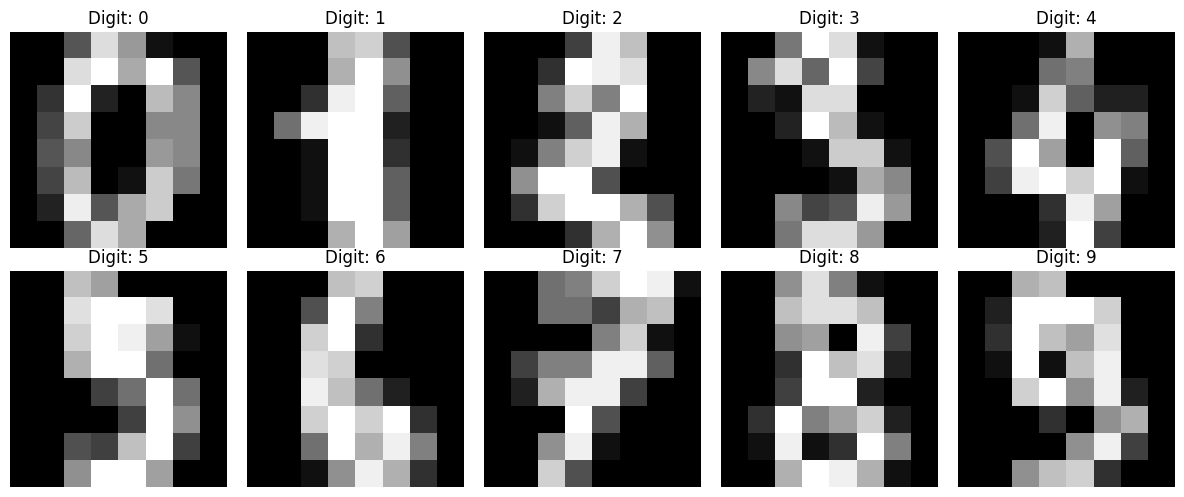

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ax, image, label in zip(axes.ravel(), digits.images[:10], y[:10]):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Digit: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
print("Missing values:", np.isnan(X).sum())

Missing values: 0


In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (1797, 64)


In [7]:
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

print("Original dimensions:", X_scaled.shape[1])
print("PCA dimensions:", X_pca_full.shape[1])

Original dimensions: 64
PCA dimensions: 64


In [8]:
explained_variance = pca_full.explained_variance_ratio_

print("Explained variance by each component:")
print(explained_variance)

Explained variance by each component:
[0.12033916 0.09561054 0.08444415 0.06498408 0.04860155 0.0421412
 0.03942083 0.03389381 0.02998221 0.02932003 0.02781805 0.02577055
 0.02275303 0.0222718  0.02165229 0.01914167 0.01775547 0.01638069
 0.0159646  0.01489191 0.0134797  0.01271931 0.01165837 0.01057647
 0.00975316 0.00944559 0.00863014 0.00836643 0.00797693 0.00746471
 0.00725582 0.00691911 0.00653909 0.00640793 0.00591384 0.00571162
 0.00523637 0.00481808 0.00453719 0.00423163 0.00406053 0.00397085
 0.00356493 0.00340787 0.00327835 0.00311032 0.00288575 0.00276489
 0.00259175 0.00234483 0.00218257 0.00203598 0.00195512 0.00183318
 0.00167946 0.00161236 0.00147763 0.00135118 0.00125101 0.00103696
 0.00082535 0.         0.         0.        ]


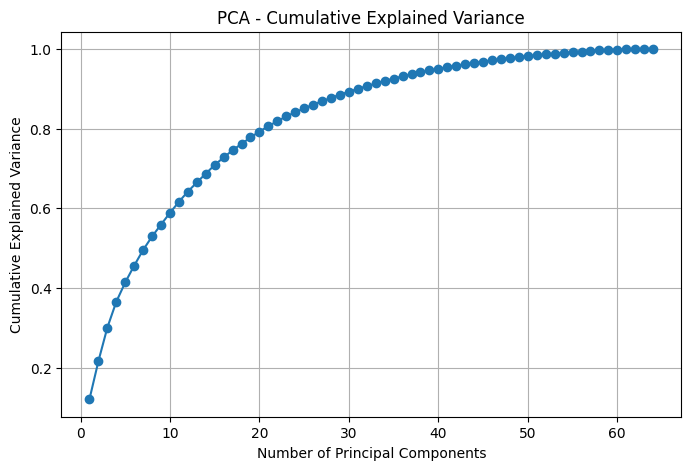

In [9]:
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")
plt.grid(True)

plt.show()

In [10]:
pca_2d = PCA(n_components=2)

X_pca_2d = pca_2d.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_pca_2d.shape)

print("\nExplained variance ratio:")
print(pca_2d.explained_variance_ratio_)

print("\nTotal variance retained:",
      pca_2d.explained_variance_ratio_.sum())

Original shape: (1797, 64)
Reduced shape: (1797, 2)

Explained variance ratio:
[0.12033916 0.09561054]

Total variance retained: 0.21594970500832789


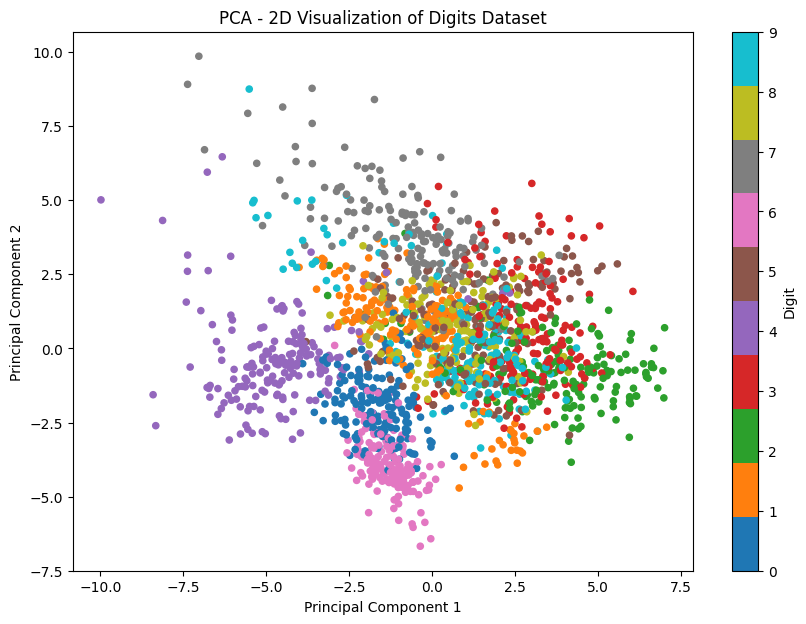

In [11]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=y,
    cmap="tab10",
    s=20
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - 2D Visualization of Digits Dataset")

plt.colorbar(scatter, label="Digit")

plt.show()

In [12]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("t-SNE shape:", X_tsne.shape)

Original shape: (1797, 64)
t-SNE shape: (1797, 2)


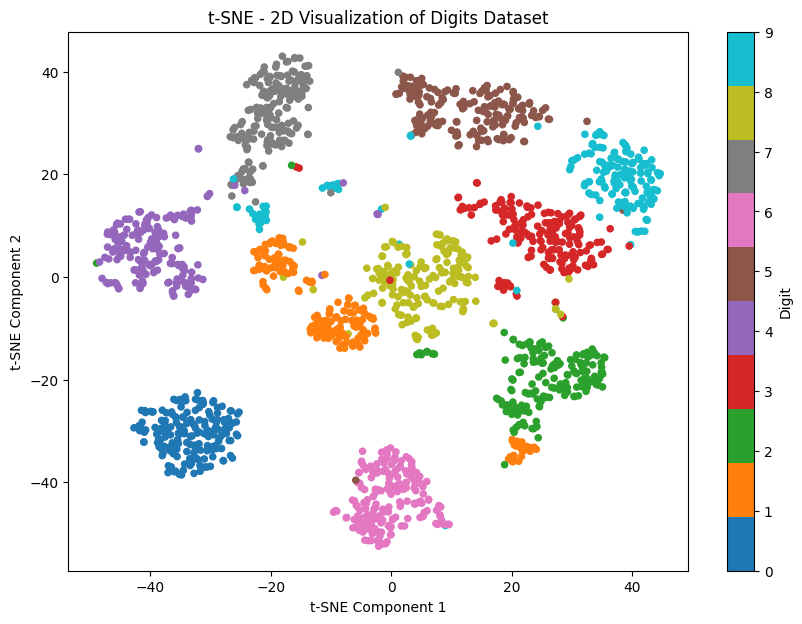

In [13]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap="tab10",
    s=20
)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE - 2D Visualization of Digits Dataset")

plt.colorbar(scatter, label="Digit")

plt.show()

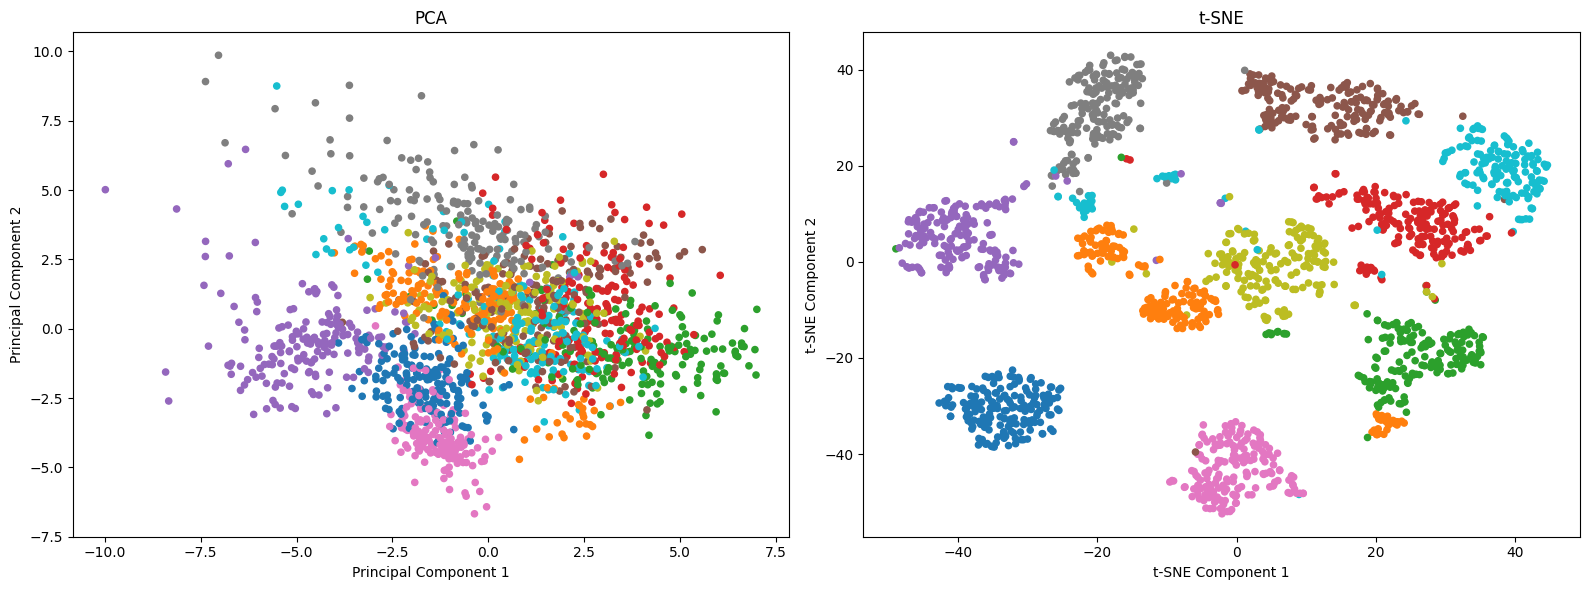

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=y,
    cmap="tab10",
    s=20
)

axes[0].set_title("PCA")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

axes[1].scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap="tab10",
    s=20
)

axes[1].set_title("t-SNE")
axes[1].set_xlabel("t-SNE Component 1")
axes[1].set_ylabel("t-SNE Component 2")

plt.tight_layout()
plt.show()

In [15]:
print("""
PCA Interpretation:
PCA reduces the dimensionality of the dataset while attempting
to preserve the maximum amount of variance using principal components.

t-SNE Interpretation:
t-SNE maps high-dimensional data into a low-dimensional space
while attempting to preserve local similarities between data points.

Comparison:
PCA is useful when we want a compact representation of the data
and information about explained variance.

t-SNE is particularly useful for visualizing complex relationships
and local groups in high-dimensional datasets.
""")


PCA Interpretation:
PCA reduces the dimensionality of the dataset while attempting
to preserve the maximum amount of variance using principal components.

t-SNE Interpretation:
t-SNE maps high-dimensional data into a low-dimensional space
while attempting to preserve local similarities between data points.

Comparison:
PCA is useful when we want a compact representation of the data
and information about explained variance.

t-SNE is particularly useful for visualizing complex relationships
and local groups in high-dimensional datasets.

